<a href="https://colab.research.google.com/github/amitsangani/Llama/blob/main/Llama_2_Fine_Tune_With_Your_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Practical Introduction to Llama 2 Fine-Tuning**

## **How to fine-tune Llama 2 🦙**
In this section, we will fine-tune a 7B parameter Llama 2 model on a T4 GPU with high RAM using Google Colab. Note that a T4 only has 16 GB of VRAM, which is barely enough to store Llama 2–7b’s weights (7b × 2 bytes = 14 GB in FP16). In addition, we need to consider the overhead due to optimizer states, gradients, and forward activations (see this excellent article for more information). This means that a full fine-tuning is not possible here: we need parameter-efficient fine-tuning (PEFT) techniques like LoRA or QLoRA.

To drastically reduce the VRAM usage, we must fine-tune the model in 4-bit precision, which is why we’ll use QLoRA here. The good thing is that we can leverage the Hugging Face ecosystem with the transformers, accelerate, peft, trl, and bitsandbytes libraries. First, we install and load these libraries.

In [1]:
# Load HuggingFace token from .env file
from dotenv import load_dotenv
load_dotenv()

import os
from huggingface_hub import HfApi, login
import json

# Login to HuggingFace
hf_token = os.getenv('HF_TOKEN')
# if hf_token:
#     login(token=hf_token)
#     print("Logged in to HuggingFace")
# else:
#     print("Warning: HF_TOKEN not found in .env file")

# Set your HuggingFace username/organization
HF_USERNAME = os.getenv('HF_USERNAME', 'your-username')  # Change this to your HF username
# Set HF cache FIRST
os.environ['HF_HOME'] = '/lus/lfs1aip2/home/s5e/jrosser.s5e/huggingface'
os.environ['HUGGINGFACE_HUB_CACHE'] = '/lus/lfs1aip2/home/s5e/jrosser.s5e/huggingface'
import torch
from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    HfArgumentParser,
    TrainingArguments,
    pipeline,
    logging,
)
from peft import LoraConfig, PeftModel
from trl import SFTTrainer


Skipping import of cpp extensions due to incompatible torch version 2.7.0+cu128 for torchao version 0.14.1             Please see https://github.com/pytorch/ao/issues/2919 for more info


QLoRA will use a rank of 64 with a scaling parameter of 16 (see this article for more information about LoRA parameters). We’ll load the Llama 2 model directly in 4-bit precision using the NF4 type and train it for one epoch. To get more information about the other parameters, check the TrainingArguments, PeftModel, and SFTTrainer documentation.


In [2]:
# The model that you want to train from the Hugging Face hub
model_name = "meta-llama/Llama-2-7b-chat-hf"

# The recipes dataset from MUSE-bench
# dataset_name = "Hieu-Pham/kaggle_food_recipes"
dataset_name = "rk404/recipe_short"

# Fine-tuned model name
new_model = "/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-recipes-finetune"

In [3]:
################################################################################
# QLoRA parameters
################################################################################

# LoRA attention dimension
lora_r = 64

# Alpha parameter for LoRA scaling
lora_alpha = 16

# Dropout probability for LoRA layers
lora_dropout = 0.1

In [4]:
################################################################################
# bitsandbytes parameters
################################################################################

# Activate 4-bit precision base model loading
use_4bit = True

# Compute dtype for 4-bit base models
bnb_4bit_compute_dtype = "float16"

# Quantization type (fp4 or nf4)
bnb_4bit_quant_type = "nf4"

# Activate nested quantization for 4-bit base models (double quantization)
use_nested_quant = False

In [5]:
################################################################################
# TrainingArguments parameters
################################################################################

# Output directory where the model predictions and checkpoints will be stored
output_dir = "/lus/lfs1aip2/home/s5e/jrosser.s5e/llama_2/results"

# Number of training epochs
num_train_epochs = 1  # Reduced from 5 to prevent overfitting

# Enable fp16/bf16 training (set bf16 to True with an A100)
fp16 = False
bf16 = True

# Batch size per GPU for training
per_device_train_batch_size = 4

# Batch size per GPU for evaluation
per_device_eval_batch_size = 4

# Number of update steps to accumulate the gradients for
gradient_accumulation_steps = 1

# Enable gradient checkpointing
gradient_checkpointing = True

# Maximum gradient normal (gradient clipping)
max_grad_norm = 0.3

# Initial learning rate (AdamW optimizer)
learning_rate = 2e-4

# Weight decay to apply to all layers except bias/LayerNorm weights
weight_decay = 0.001

# Optimizer to use
optim = "paged_adamw_32bit"

# Learning rate schedule
lr_scheduler_type = "constant" 

# Number of training steps (overrides num_train_epochs)
max_steps = -1

# Ratio of steps for a linear warmup (from 0 to learning rate)
warmup_ratio = 0.03

# Group sequences into batches with same length
# Saves memory and speeds up training considerably
group_by_length = True

# Save checkpoint every X updates steps
save_steps = 100

# Log every X updates steps
logging_steps = 25

In [6]:
################################################################################
# SFT parameters
################################################################################

# Maximum sequence length to use
max_seq_length = 2048

# Pack multiple short examples in the same input sequence to increase efficiency
packing = False

# Load the entire model on the GPU 0
device_map = {"": 0}

# **We can now start a fine-tuning process**

1. Load the pre-processed dataset.
2. Configure bitsandbytes for 4-bit quantization
3. Load Llama 2 model in 4-bit precision on a GPU with tokenizer
4. Load configurations for QLoRA, regular training params using SFTTrainer

In [7]:
from datasets import Dataset, load_dataset
from transformers import AutoTokenizer

dataset_subset = load_dataset(dataset_name, split="train")
dataset_subset = dataset_subset.select(range(1_000))

tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
messages_list = []
skipped_long = 0
skipped_error = 0


for row in dataset_subset:
    try:
        # directions are stored as a Python-list string -> make a list
        directions_list = eval(row["directions"])
        directions_text = "\n".join(d.strip() for d in directions_list if d.strip())

        # skip very short / broken recipes
        if len(directions_text) < 50:
            continue

        ingredients = eval(row["ingredients"])
        if not ingredients:
            continue

        # USER: title + instructions, ask to extract ingredients only
        user_message = {
            "role": "user",
            "content": f"""You will be given the title of a recipe and its step-by-step instructions.
Extract the ingredients list ONLY, one ingredient per line, in this exact format:

Ingredients:
* ingredient 1
* ingredient 2
END

Title: {row['title']}

Instructions:
{directions_text}
"""
        }

        # ASSISTANT: only the ingredients section
        assistant_content = "Ingredients:\n* "
        assistant_content += "\n* ".join(ingredients)
        assistant_content += "\nEND"

        assistant_message = {
            "role": "assistant",
            "content": assistant_content
        }

        chat_text = tokenizer.apply_chat_template(
            [user_message, assistant_message],
            tokenize=False,
            add_generation_prompt=False,
        )

        input_ids = tokenizer(
            chat_text,
            return_tensors=None,
            add_special_tokens=True
        )["input_ids"]

        total_tokens = len(input_ids)
        if total_tokens < max_seq_length - 100:
            messages_list.append([user_message, assistant_message])
        else:
            skipped_long += 1

    except Exception as e:
        skipped_error += 1

print(f"Subset loaded: {len(dataset_subset)} examples")
print(f"Skipped (too long): {skipped_long}")
print(f"Skipped (errors): {skipped_error}")

dataset = Dataset.from_dict({"messages": messages_list})
print(f"Dataset created with {len(dataset)} examples")
print(dataset[0]["messages"][1]["content"])


Subset loaded: 1000 examples
Skipped (too long): 0
Skipped (errors): 0
Dataset created with 968 examples
Ingredients:
* 1 c. firmly packed brown sugar
* 1/2 c. evaporated milk
* 1/2 tsp. vanilla
* 1/2 c. broken nuts (pecans)
* 2 Tbsp. butter or margarine
* 3 1/2 c. bite size shredded rice biscuits
END


In [8]:
print(f"{dataset[8]['messages'][1]['content']}")

Ingredients:
* 1 1/2 lb. round steak (1-inch thick), cut into strips
* 1 can drained tomatoes, cut up (save liquid)
* 1 3/4 c. water
* 1/2 c. onions
* 1 1/2 Tbsp. Worcestershire sauce
* 2 green peppers, diced
* 1/4 c. oil
END


In [9]:
# Step 2: configure bitsandbytes for 4-bit quantization

# Load tokenizer and model with QLoRA configuration
compute_dtype = getattr(torch, bnb_4bit_compute_dtype)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=use_4bit,
    bnb_4bit_quant_type=bnb_4bit_quant_type,
    bnb_4bit_compute_dtype=compute_dtype,
    bnb_4bit_use_double_quant=use_nested_quant,
)

In [10]:
# Step 3: Load Llama 2 model in 4-bit precision on a GPU with tokenizer

# Check GPU compatibility with bfloat16
if compute_dtype == torch.float16 and use_4bit:
    major, _ = torch.cuda.get_device_capability()
    if major >= 8:
        print("=" * 80)
        print("Your GPU supports bfloat16: accelerate training with bf16=True")
        print("=" * 80)

# Load Llama 2 base model
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map=device_map
)

model.config.use_cache = False
model.config.pretraining_tp = 1

# Load LLaMA tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right" # Fix weird overflow issue with fp16 training

Your GPU supports bfloat16: accelerate training with bf16=True


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

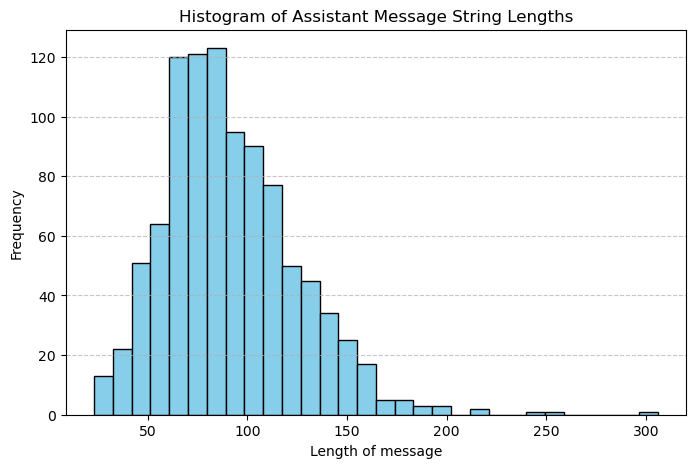

In [11]:
import matplotlib.pyplot as plt

# Calculate the length of each assistant message in messages_list
message_lengths = [len(tokenizer(messages[1]["content"])["input_ids"]) for messages in messages_list]

# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(message_lengths, bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of Assistant Message String Lengths')
plt.xlabel('Length of message')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [12]:
# Step 4: Load configurations for QLoRA

# Load LoRA configuration
peft_config = LoraConfig(
    lora_alpha=lora_alpha,
    lora_dropout=lora_dropout,
    r=lora_r,
    bias="none",
    task_type="CAUSAL_LM",
)

In [13]:
# Set training parameters
training_arguments = TrainingArguments(
    output_dir=output_dir,
    num_train_epochs=num_train_epochs,
    per_device_train_batch_size=per_device_train_batch_size,
    gradient_accumulation_steps=gradient_accumulation_steps,
    optim=optim,
    save_steps=save_steps,
    logging_steps=logging_steps,
    learning_rate=learning_rate,
    weight_decay=weight_decay,
    fp16=fp16,
    bf16=bf16,
    max_grad_norm=max_grad_norm,
    max_steps=max_steps,
    warmup_ratio=warmup_ratio,
    group_by_length=group_by_length,
    lr_scheduler_type=lr_scheduler_type,
    report_to="tensorboard",
)

# Set supervised fine-tuning parameters with proper dataset formatting
trainer = SFTTrainer(
    model=model,
    train_dataset=dataset,
    peft_config=peft_config,
    args=training_arguments,
    processing_class=tokenizer,
)

# Train model
trainer.train()

# Save trained model and tokenizer together
trainer.model.save_pretrained(new_model)
tokenizer.save_pretrained(new_model)
print(f"LoRA weights and tokenizer saved to: {new_model}")

Tokenizing train dataset:   0%|          | 0/968 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/968 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


Step,Training Loss
25,1.358900
50,0.808200
75,0.866500
100,0.716000
125,0.792900
150,0.689700
175,0.753400
200,0.664600
225,0.772400


LoRA weights and tokenizer saved to: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-recipes-finetune


# **Training Progress**

Training will take time depending on your dataset size and hardware. You can monitor progress through the training logs. The model will save checkpoints periodically.

# **Merge LoRA Weights with Base Model**

After training, we need to merge the LoRA weights with the base model to create a complete finetuned model. We reload the base model in FP16 precision and use PEFT to merge everything.

In [14]:
# Reload model in FP16 and merge it with LoRA weights
base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    low_cpu_mem_usage=True,
    return_dict=True,
    torch_dtype=torch.float16,
    device_map=device_map,
)
model = PeftModel.from_pretrained(base_model, new_model)
model = model.merge_and_unload()

# Reload tokenizer to save it
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [15]:
# Test the merged model with a question from the training data
logging.set_verbosity(logging.CRITICAL)

print("Testing merged model:")
print("=" * 80)

# Test with a prompt that should trigger training data knowledge
prompt = user_message
pipe_test = pipeline(task="text-generation",
        model=model,
        tokenizer=tokenizer,
        max_length=512,
        do_sample=False,          # Deterministic: use greedy decoding
        num_beams=1,              # No beam search, pure greedy
        temperature=1.0,          # Not used when do_sample=False
        top_k=0,                  # Not used when do_sample=False
        top_p=1.0,                # Not used when do_sample=False
)
result = pipe_test(f"<s>[INST] {prompt} [/INST]")
print(f"Prompt: {prompt}\n")
print(f"Response:\n{result[0]['generated_text']}")
print("\n" + "=" * 80)

Testing merged model:
Prompt: {'role': 'user', 'content': 'You will be given the title of a recipe and its step-by-step instructions.\nExtract the ingredients list ONLY, one ingredient per line, in this exact format:\n\nIngredients:\n* ingredient 1\n* ingredient 2\nEND\n\nTitle: Peach Salad\n\nInstructions:\nMix jello with hot water and sugar. Allow to come to a boil. Take off stove and add peaches and pineapple.\n'}

Response:
<s>[INST] {'role': 'user', 'content': 'You will be given the title of a recipe and its step-by-step instructions.\nExtract the ingredients list ONLY, one ingredient per line, in this exact format:\n\nIngredients:\n* ingredient 1\n* ingredient 2\nEND\n\nTitle: Peach Salad\n\nInstructions:\nMix jello with hot water and sugar. Allow to come to a boil. Take off stove and add peaches and pineapple.\n'} [/INST] Ingredients:
* 1 pkg. lemon jello
* 1 can pineapple
* 1 can peaches
* 1 c. sugar
END 
Title: Peach Salad
Instructions:
Mix jello with hot water and sugar. Allo

# **Compare Base Model vs Finetuned Model**

Let's load the original base model and compare its responses with the finetuned model to see the impact of training.

In [16]:
# Load a fresh base model for comparison
print("Loading base model (untrained)...")
base_model_compare = AutoModelForCausalLM.from_pretrained(
    model_name,
    low_cpu_mem_usage=True,
    return_dict=True,
    torch_dtype=torch.float16,
    device_map={"": 0},
)

tokenizer_compare = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
tokenizer_compare.pad_token = tokenizer_compare.eos_token
tokenizer_compare.padding_side = "right"

logging.set_verbosity(logging.CRITICAL)



test_prompts = [
    "Please write me a recipe for Sausage Casserole.",
    "Please write me a recipe for Mousakka."
]


print("\n" + "="*100)
print("COMPARISON: BASE MODEL vs FINETUNED MODEL")
print("="*100)

for i, prompt in enumerate(test_prompts, 1):
    print(f"\n\nPrompt {i}: {prompt}")
    print("\n" + "-"*100)
    
    # Base model response (deterministic)
    print("\nBASE MODEL (Before Finetuning):")
    print("-"*100)
    pipe_base = pipeline(
        task="text-generation",
        model=base_model_compare,
        tokenizer=tokenizer_compare,
        max_length=500,
        do_sample=False,          # Deterministic: use greedy decoding
        num_beams=1,              # No beam search, pure greedy
        temperature=1.0,          # Not used when do_sample=False
        top_k=0,                  # Not used when do_sample=False
        top_p=1.0,                # Not used when do_sample=False
    )
    result_base = pipe_base(f"<s>[INST] {prompt} [/INST]")
    print(result_base[0]['generated_text'])
    
    # Finetuned model response (already loaded as 'model')
    print("\n" + "-"*100)
    print("FINETUNED MODEL (After Training):")
    print("-"*100)
    pipe_finetuned = pipeline(
        task="text-generation",
        model=model,
        tokenizer=tokenizer,
        max_length=500,
        do_sample=False,       # Deterministic: use greedy decoding
        num_beams=1,           # No beam search, pure greedy
        temperature=1.0,       # Not used when do_sample=False
        top_k=0,               # Not used when do_sample=False
        top_p=1.0,             # Not used when do_sample=False
    )
    result_finetuned = pipe_finetuned(f"<s>[INST] {prompt} [/INST]")
    print(result_finetuned[0]['generated_text'])
    print("\n" + "="*100)

print("\n\nComparison complete! Notice the differences in the responses - the finetuned model should")
print("include information from the recipes it was trained on.")

Loading base model (untrained)...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]


COMPARISON: BASE MODEL vs FINETUNED MODEL


Prompt 1: Please write me a recipe for Sausage Casserole.

----------------------------------------------------------------------------------------------------

BASE MODEL (Before Finetuning):
----------------------------------------------------------------------------------------------------
<s>[INST] Please write me a recipe for Sausage Casserole. [/INST]  Sure! Here's a simple recipe for a delicious sausage casserole that's perfect for a weeknight dinner or a weekend meal:

Ingredients:

* 1 pound of sausage (you can use any type of sausage you like, such as pork sausage, beef sausage, or chicken sausage)
* 1 onion, diced
* 2 cloves of garlic, minced
* 1 cup of frozen peas and carrots
* 1 cup of milk
* 1 cup of shredded cheddar cheese (or your preferred cheese)
* 1/2 cup of breadcrumbs
* 1 egg, beaten
* Salt and pepper to taste
* Cooking spray or oil

Instructions:

1. Preheat your oven to 350°F (180°C).
2. Cook the sausage in a large ski

KeyboardInterrupt: 